In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix
import pynapple as nap
from spatial_manifolds.toroidal import *
from spatial_manifolds.behaviour_plots import *

from spatial_manifolds.mlencoding import *
from spatial_manifolds.circular_decoder import circular_decoder, cross_validate_decoder, cross_validate_decoder_time, circular_nanmean
from spatial_manifolds.data.curation import curate_clusters
from scipy.stats import zscore
from spatial_manifolds.util import gaussian_filter_nan
from spatial_manifolds.predictive_grid import compute_travel_projected, wrap_list
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.detect_grids import *
from spatial_manifolds.brainrender_helper import *

import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
fig_path = '/Users/harryclark/Documents/figs/FIGURE1/'
mouse = 28
day = 25

# good examples include 
#mice = [25, 25, 26, 27, 29, 28]
#days = [25, 24, 18, 26, 23, 25]

28 25
optimal travel lag is 9.75975975975976 cm based on kde of travel at max spatial information
optimal travel lag is 9.75975975975976 cm
optimal travel lag is 9.75975975975976 cm based on kde of travel at max spatial information
optimal travel lag is 9.75975975975976 cm
there are 106 non_grid and non_spatial_cells
there are 23 grid_cells
there are 94 non grid spatial cells
there are 12 non spatial cells
there are 0 speed cells
there are 129 cells
for the non-grid spatial cells the unique locations are ['ENTm3' 'ENTm5' 'PAR' 'VISpl5' 'VISpl6a' 'VISpor5']
for the grid cells the unique locations are ['ENTm3' 'ENTm5']
there are 106 non_grid and non_spatial_cells
there are 23 grid_cells
there are 94 non grid spatial cells
there are 12 non spatial cells
there are 0 speed cells
there are 129 cells
for the non-grid spatial cells the unique locations are ['ENTm3' 'ENTm5' 'PAR' 'VISpl5' 'VISpl6a' 'VISpor5']
for the grid cells the unique locations are ['ENTm3' 'ENTm5']
unique brain regions ['E

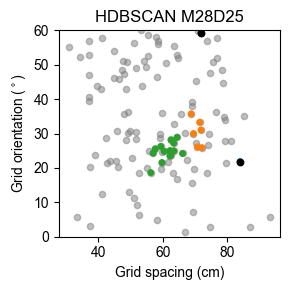

for module 0, there are 6 cells with average spacing 70.76972276610992
for module 1, there are 15 cells with average spacing 61.33629235763494
28 25
for module 1, there are 15 cells
for module 1, there are 15 cells
for module 0, there are 6 cells
for module 0, there are 6 cells
plotting vr rate maps using cluster_ids [126, 139, 147, 149, 151, 153, 154, 155, 156, 158, 160, 162, 174, 188, 284]
plotting vr rate maps using cluster_ids [126, 139, 147, 149, 151, 153, 154, 155, 156, 158, 160, 162, 174, 188, 284]


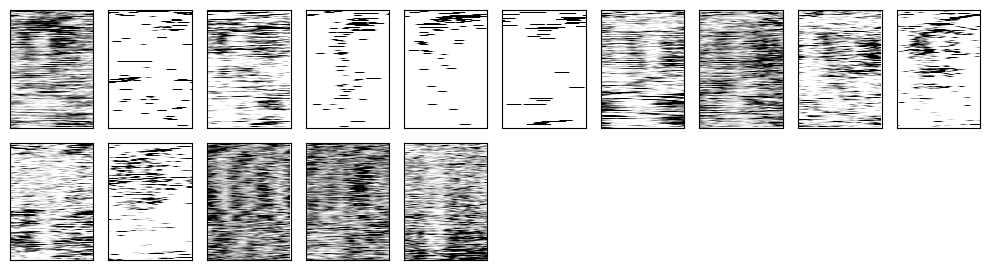

plotting vr rate maps using cluster_ids [99, 108, 140, 242, 258, 287]


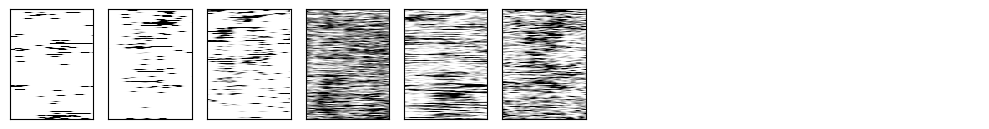

plotting vr rate maps using cluster_ids [1, 3, 10, 14, 15, 22, 25, 28, 30, 39, 41, 46, 48, 51, 55, 56, 57, 59, 61, 69, 73, 75, 77, 78, 83, 87, 96, 113, 117, 121, 124, 130, 136, 170, 176, 186, 221, 226, 227, 228, 232, 236, 244, 250, 254, 264, 273, 276, 285, 294, 310, 313, 327, 328, 333, 337, 338, 339, 341, 344, 347, 352, 362, 364, 365, 369, 371, 377, 379, 380, 383, 385, 386, 387, 391, 392, 393, 403, 404, 406, 407, 412, 414, 423, 425, 436, 442, 447, 453, 461, 462, 476, 478, 484]


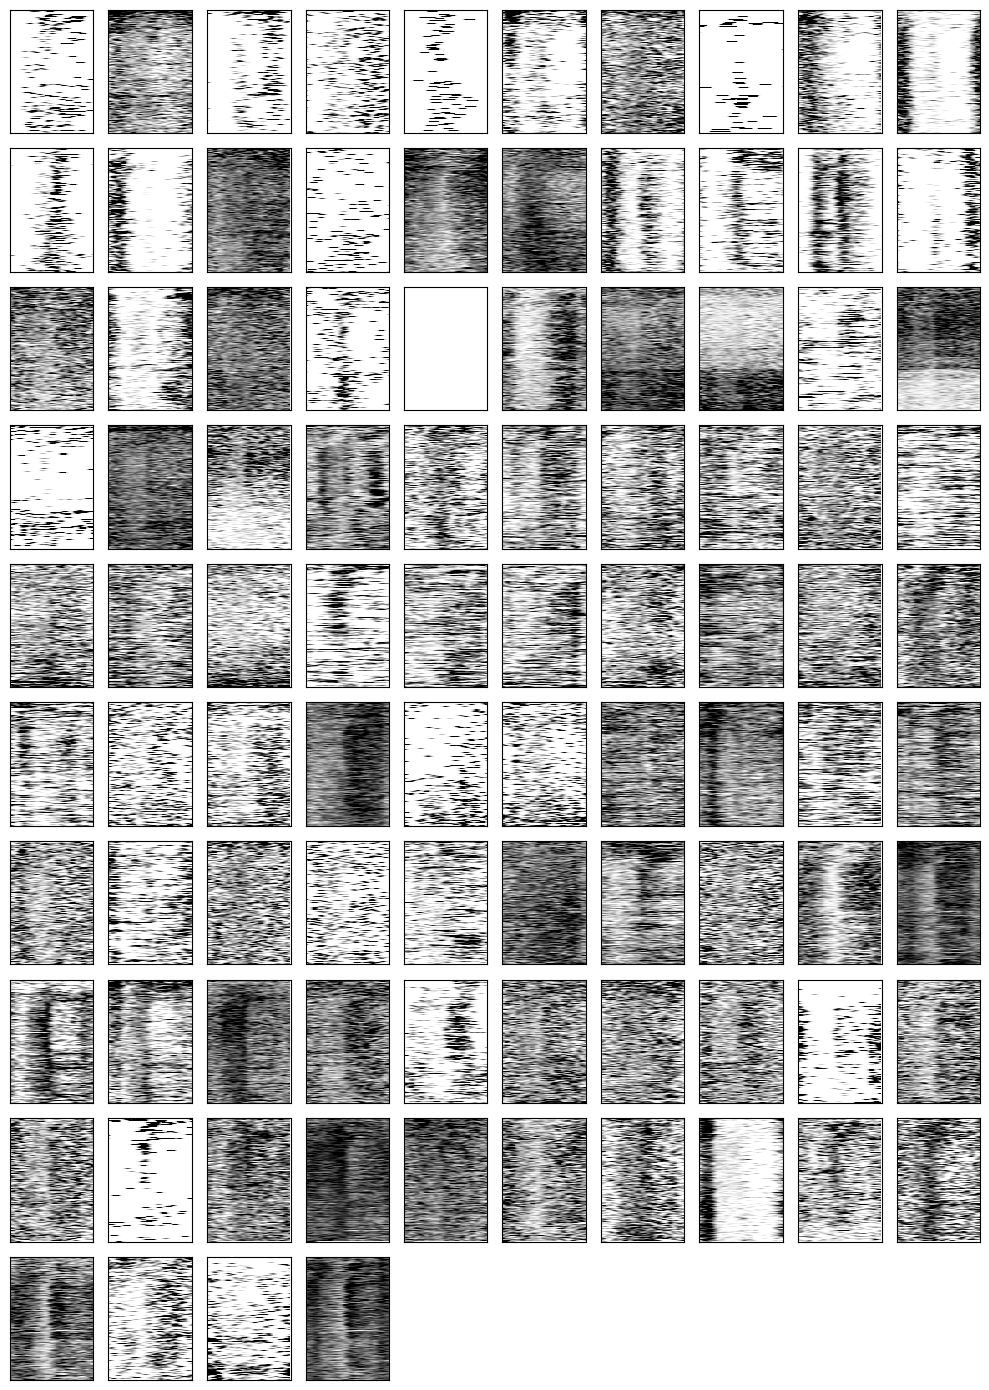

plotting vr rate maps using cluster_ids [202, 316, 326, 335, 342, 349, 353, 354, 356, 366, 419, 489]


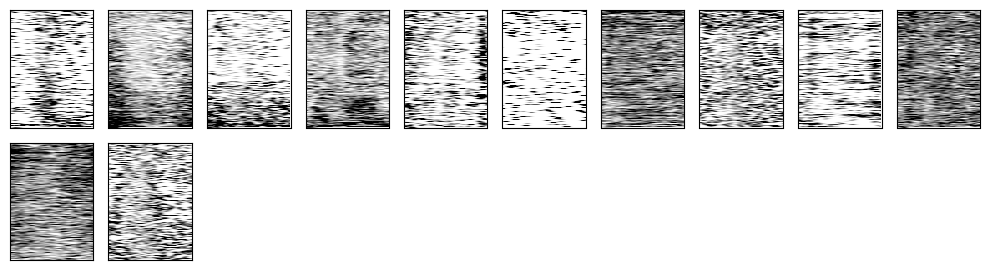

plotting vr rate maps using cluster_ids [99, 108, 126, 139, 140, 147, 149, 151, 153, 154, 155, 156, 158, 160, 162, 174, 177, 188, 242, 258, 284, 287, 363]


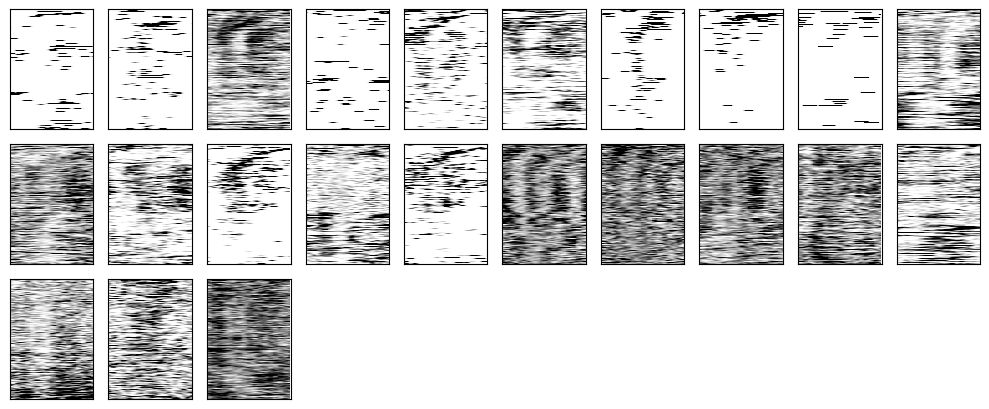

plotting vr rate maps using cluster_ids []


In [3]:
gcs, ngs, ns, sc, ngs_ns, all = cell_classification_of1(mouse, day, percentile_threshold=95) # subset
mec, para, pre, sub, vis, cere, other, all_by_anatomy = cell_classification_anatomy(mouse, day)

ngs = reconstruct_shank_id(ngs, mouse, colname='probe_x') 
gcs = reconstruct_shank_id(gcs, mouse, colname='probe_x')

g_m_ids, g_m_cluster_ids = HDBSCAN_grid_modules(gcs, all, mouse, day, min_cluster_size=3, cluster_selection_epsilon=3, 
                                                figpath=fig_path, curate_with_vr=False, curate_with_brain_region=True, plot_curate=False) # create grid modules using HDBSCAN    

plot_grid_modules_rate_maps(gcs, g_m_ids, g_m_cluster_ids, mouse, day, figpath=fig_path)

# we now have cluster ids classified into modules, non grid spatial cells and non spatial cells 
# as defined by activity in the open field
g_m_cluster_ids = sorted(g_m_cluster_ids, key=len, reverse=True) 
cluster_ids_by_group = []
cluster_ids_by_group.extend(g_m_cluster_ids) # grid cells by module [0,1,2...]
cluster_ids_by_group.append(ngs.cluster_id.values.tolist()) # non grid spatial [-4]
cluster_ids_by_group.append(ns.cluster_id.values.tolist()) # non spatial cells [-3]
cluster_ids_by_group.append(gcs.cluster_id.values.tolist()) # all grid cells [-2]
cluster_ids_by_group.append(sc.cluster_id.values.tolist()) # speed cells [-1]

for m, cluster_ids in enumerate(cluster_ids_by_group):
    plot_vr_rate_maps(mouse, day, cluster_ids, label=f'{m}', figpath=fig_path)


In [4]:
Mouse = f'M{mouse}'
data_paths = [f"/Users/harryclark/Documents/brainrender/probe_data/{Mouse}_probe_locations_{a}.mat" for a in [1,2,3,4]]
shank_offsets_SC = pd.read_csv('/Users/harryclark/Documents/brainrender/probe_data/shank_offsets.csv')
clusters_df = pd.read_csv(f'/Users/harryclark/Documents/brainrender/probe_data/extremum_channel_locations_kilosort4_0.csv')
clusters_df = clusters_df[clusters_df['mouse'] == mouse]
shank_offsets_SC = shank_offsets_SC[shank_offsets_SC['mouse'] == mouse]
clusters_df = reconstruct_shank_id(clusters_df, mouse)
probes_locs = [read_probe_mat(data_path) for data_path in data_paths]
adjusted_probes_locs_CCF = np.array([adjust_probe_locs(probe_locs) for probe_locs in probes_locs])
adjusted_probe_locs_SC, adjusted_probe_locs_CCF = correct_for_left_side(adjusted_probes_locs_CCF)
adjusted_probe_locs_SC, adjusted_probe_locs_CCF = adjust_to_shank_offsets(adjusted_probe_locs_SC, shank_offsets_SC)

ymin = -300; ymax = 3000
xmin = -200; xmax = 1000
xs = np.arange(xmin, xmax, 1)
ys = np.arange(ymin, ymax, 1)

annotations = np.zeros((len(ys), len(xs)), dtype=object)
for yi, y in enumerate(ys):
    for xi, x in enumerate(xs):
        coord_SC, coord_CCF  = brain_coord_from_xy(x, y, adjusted_probe_locs_SC, shank_id=0)
        # use the CCF coordinates, get an index and look up the annotation in the brainrender allen_brain_10um volume
        z_CCF, y_CCF, x_CCF = np.round(coord_CCF/10).astype(int)
        annotation_index = annotations_set[z_CCF,y_CCF,x_CCF]
        if len(structure_set[structure_set['id'] == annotation_index]) ==1:
            annotation = structure_set[structure_set['id'] == annotation_index]['acronym'].iloc[0]
        else:
            annotation ='root' # out of brain
        annotations[yi,xi] = annotation
annotation_colors = get_annotation_colors_2D(annotations)

hi


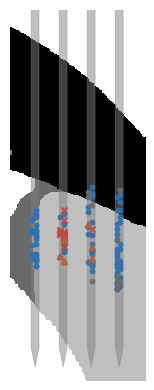

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
unique_colors = np.unique(annotation_colors)
for color in unique_colors:
    border_points = extract_border(annotation_colors, color, only_border=False)
    x_points = xs[border_points[:, 1]]
    y_points = ys[border_points[:, 0]]
    ax.scatter(x_points, y_points, color=color, s=1, label=color, rasterized=True)
plot_NP2_probe(ax, sorting_analyzer_path='/Users/harryclark/Downloads/kilosort4_sa', 
               probe_alpha=0.5, contacts_alpha=0.0, probe_color='grey', probe_edgecolor='black')
# plot cell locations 
ax.scatter(ngs.probe_x.values, ngs.probe_y.values, marker='o', color="#3171ae", alpha=0.9, s=10)
ax.scatter(ns.probe_x.values, ns.probe_y.values, marker='o', color="#6c6c6c", alpha=0.9, s=10)

markers = ['x','^', 's']
colors=["#c04744", "#B6632F", "#c09744"]
for i, cluster_ids in enumerate(g_m_cluster_ids):
    gc_m = gcs[np.isin(gcs.cluster_id, cluster_ids)]
    ax.scatter(gc_m.probe_x.values, gc_m.probe_y.values, marker=markers[i], color=colors[i], alpha=0.9, s=20)
plt.tight_layout()
plt.savefig(f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_3_xgboost/M{mouse}D{day}_probe_brainrender.pdf', bbox_inches='tight', dpi=500) # use tight layout to avoid cutting off labels
plt.show()

In [6]:
tcs, tcs_time, _, last_ephys_bin, beh, clusters = compute_vr_tcs(mouse,day, apply_zscore=False, apply_guassian_filter=False)

last_ephys_time_bin = clusters[clusters.index[0]].count(bin_size=time_bs, time_units = 'ms').index[-1]

# time binned variables for later
ep = nap.IntervalSet(start=0, end=last_ephys_time_bin, time_units = 's')
speed_in_time = np.array(beh['S'].bin_average(bin_size=time_bs, time_units = 'ms', ep=ep))
dt_in_time = np.array(beh['travel'].bin_average(bin_size=time_bs, time_units = 'ms', ep=ep)-((beh['trial_number'][0]-1)*tl))
pos_in_time = dt_in_time%tl
trial_number_in_time = (dt_in_time//tl)+beh['trial_number'][0]

if np.any(np.isnan(pos_in_time)):
    series = pd.Series(dt_in_time)
    filled_series = series.ffill().bfill()
    dt_in_time = np.array(filled_series)
    pos_in_time = dt_in_time%tl
    trial_number_in_time = (dt_in_time//tl)+beh['trial_number'][0]

if np.any(np.isnan(speed_in_time)):
    series = pd.Series(speed_in_time)
    filled_series = series.ffill().bfill()
    speed_in_time = np.array(speed_in_time)

# compute the spectrogram and labels from the most adunant grid module
peak_indices = [28, 44, 60, 76]
cluster_ids = g_m_cluster_ids[0]
tcs_to_use = {cluster_id: tcs[cluster_id] for cluster_id in cluster_ids if cluster_id in tcs}
results = spectral_analysis(tcs_to_use, tl, bs=bs)
spectrograms = results[3] 
fvalid = results[5]
S = spectrograms.mean(0)
max_peaks = np.argmax(S, axis=0)
labels = np.isin(max_peaks, peak_indices).astype(int)

# compute trial labels for task anchoring to use in the xgboost model mask
tc = tcs[126] # example grid cell
tc = gaussian_filter(np.nan_to_num(tc).astype(np.float64), sigma=2.5)
tc = tc[:last_ephys_bin] # only want bins with ephys data in it
trial_labels = get_kmeans_spatial_labels(tc, labels, bs=bs, tl=tl) # reuse kmeans function to get the labels based on the task anchoring
print(trial_labels)

Identified 1 candidate modules
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0.
 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [7]:
xgb_history = MLencoding(tunemodel = 'xgboost',
                         cov_history = True, spike_history=False, # We can choose!
                         window = time_bs, #this dataset has 100ms time bins
                         n_filters = 5,
                         max_time = 1000)

plot a grid cell

In [8]:
def compute_rolling_pr2(y_true, y_pred, trial_numbers, window_size=10):
    """
    Compute rolling pR2 values across trials using Poisson pseudo-R2.
    
    Parameters:
    -----------
    y_true : array
        True values (ground truth)
    y_pred : array  
        Predicted values
    trial_numbers : array
        Trial numbers for each time point
    window_size : int
        Number of trials to include in each rolling window
        
    Returns:
    --------
    unique_trials : array
        Trial numbers
    rolling_pr2 : array
        Rolling pR2 values for each trial
    """
    # Import the poisson_pseudoR2 function from mlencoding
    from spatial_manifolds.mlencoding import poisson_pseudoR2
    
    unique_trials = np.unique(trial_numbers)
    rolling_pr2 = np.full(len(unique_trials), np.nan)
    
    for i, trial in enumerate(unique_trials):
        # Define window around current trial
        start_trial = max(0, i - window_size//2)
        end_trial = min(len(unique_trials), i + window_size//2 + 1)
        window_trials = unique_trials[start_trial:end_trial]
        
        # Get indices for trials in window
        window_mask = np.isin(trial_numbers, window_trials)
        
        if np.sum(window_mask) > 10:  # Need minimum number of points
            y_true_window = y_true[window_mask]
            y_pred_window = y_pred[window_mask]
            
            # Remove NaN values
            valid_mask = ~(np.isnan(y_true_window) | np.isnan(y_pred_window))
            if np.sum(valid_mask) > 5:
                y_true_clean = y_true_window[valid_mask]
                y_pred_clean = y_pred_window[valid_mask]
                
                # Compute null model (mean activity in the window)
                y_null = np.mean(y_true_clean)
                
                # Compute Poisson pseudo-R2
                if len(y_true_clean) > 1 and np.var(y_true_clean) > 0:
                    pr2 = poisson_pseudoR2(y_true_clean, y_pred_clean, y_null)
                    rolling_pr2[i] = pr2 if not np.isnan(pr2) else 0
    
    return unique_trials, rolling_pr2


def compute_rolling_pr2_for_all_predictions(y_true, trial_numbers, predictions_dict, window_size=10):
    """
    Compute rolling pR2 for all prediction conditions using Poisson pseudo-R2.
    
    Parameters:
    -----------
    y_true : array
        True values (target cell activity)
    trial_numbers : array
        Trial numbers for each time point  
    predictions_dict : dict
        Dictionary with prediction names as keys and predicted values as values
    window_size : int
        Number of trials for rolling window
        
    Returns:
    --------
    results_df : DataFrame
        DataFrame with trial numbers and rolling pR2 for each condition
    """
    unique_trials = np.unique(trial_numbers)
    results = {'trial_number': unique_trials}
    
    for pred_name, y_pred in predictions_dict.items():
        _, rolling_pr2 = compute_rolling_pr2(y_true, y_pred, trial_numbers, window_size)
        results[f'rolling_pr2_{pred_name}'] = rolling_pr2
    
    return pd.DataFrame(results)

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

all_rolling_results_task_anchoring = []

for test_grid_cell_id in g_m_cluster_ids[0].copy():
    module_1_ids = g_m_cluster_ids[0].copy()
    module_1_ids.remove(test_grid_cell_id)
    shank_0_ngs = ngs[ngs.shank_id == 0].cluster_id.values.tolist()
    shank_1_ngs = ngs[ngs.shank_id == 1].cluster_id.values.tolist()
    shank_2_ngs = ngs[ngs.shank_id == 2].cluster_id.values.tolist()
    shank_3_ngs = ngs[ngs.shank_id == 3].cluster_id.values.tolist()

    all_cell_ids = all.cluster_id.values.tolist()
    all_cells_except_test = [cid for cid in all_cell_ids if cid != test_grid_cell_id and cid in tcs_time]

    cov_tcs_time_module_1 = {cluster_id: tcs_time[cluster_id] for cluster_id in module_1_ids if cluster_id in tcs_time}
    cov_tcs_time_shank_0_ngs = {cluster_id: tcs_time[cluster_id] for cluster_id in shank_0_ngs if cluster_id in tcs_time}
    cov_tcs_time_shank_1_ngs = {cluster_id: tcs_time[cluster_id] for cluster_id in shank_1_ngs if cluster_id in tcs_time}
    cov_tcs_time_shank_2_ngs = {cluster_id: tcs_time[cluster_id] for cluster_id in shank_2_ngs if cluster_id in tcs_time}
    cov_tcs_time_shank_3_ngs = {cluster_id: tcs_time[cluster_id] for cluster_id in shank_3_ngs if cluster_id in tcs_time}
    
    y = np.array(tcs_time[test_grid_cell_id])
    y_smoothed = gaussian_filter_nan(y, sigma=3)
    X  = np.stack([pos_in_time]).T

    Xm1 = np.column_stack((np.vstack(list(cov_tcs_time_module_1.values())).T)).T
    Xs0 = np.column_stack((np.vstack(list(cov_tcs_time_shank_0_ngs.values())).T)).T
    Xs1 = np.column_stack((np.vstack(list(cov_tcs_time_shank_1_ngs.values())).T)).T
    Xs2 = np.column_stack((np.vstack(list(cov_tcs_time_shank_2_ngs.values())).T)).T
    Xs3 = np.column_stack((np.vstack(list(cov_tcs_time_shank_3_ngs.values())).T)).T
    Xall = np.stack([np.array(tcs_time[cid]) for cid in all_cells_except_test]).T

    Xpos_m1 = np.column_stack((pos_in_time, np.vstack(list(cov_tcs_time_module_1.values())).T))
    X_pos_s0 = np.column_stack((pos_in_time, np.vstack(list(cov_tcs_time_shank_0_ngs.values())).T))
    X_pos_s1 = np.column_stack((pos_in_time, np.vstack(list(cov_tcs_time_shank_1_ngs.values())).T))
    X_pos_s2 = np.column_stack((pos_in_time, np.vstack(list(cov_tcs_time_shank_2_ngs.values())).T))
    X_pos_s3 = np.column_stack((pos_in_time, np.vstack(list(cov_tcs_time_shank_3_ngs.values())).T))
    Xpos_all = np.column_stack((pos_in_time, Xall))

    Y_hat_p, _ = xgb_history.fit_cv(X, y, verbose=0, continuous_folds=True)

    predictors_to_use = {
        'position': X,
        'module_1': Xm1,
        'shank_0_ngs': Xs0,
        'shank_1_ngs': Xs1,
        'shank_2_ngs': Xs2,
        'shank_3_ngs': Xs3,
        'all_cells': Xall,
        'position_plus_shank_0_ngs': Xpos_m1,
        'position_plus_shank_1_ngs': X_pos_s0,
        'position_plus_shank_2_ngs': X_pos_s1,
        'position_plus_shank_3_ngs': X_pos_s2,
        'position_plus_all_cells': Xpos_all,
    }

    for training_mode, testing_mode in zip([1,0], [0,1]):
        train_trials = beh['trials'][:len(trial_labels)]
        test_trials = beh['trials'][:len(trial_labels)]

        train_trials = train_trials[trial_labels == training_mode]['number'].values
        test_trials = test_trials[trial_labels == testing_mode]['number'].values

        train_mask = np.isin(trial_number_in_time, train_trials)
        test_mask = np.isin(trial_number_in_time, test_trials)

        train_indices = np.where(train_mask)[0]
        test_indices = np.where(test_mask)[0]

        y_full = np.array(tcs_time[test_grid_cell_id])

        predictions_dict = {}
        for name, Xmat in predictors_to_use.items():
            Y_hat, *_ = xgb_history.fit_cv_and_predefined_set(
                Xmat, y_full, train_indices, test_indices, n_cv=10, verbose=0, continuous_folds=True
            )
            predictions_dict[name] = Y_hat

        rolling_pr2_results = compute_rolling_pr2_for_all_predictions(
            y_true=y_full, 
            trial_numbers=trial_number_in_time,
            predictions_dict=predictions_dict,
            window_size=15
        )
        rolling_pr2_results['test_grid_cell_id'] = test_grid_cell_id
        rolling_pr2_results['train_mode'] = training_mode
        rolling_pr2_results['test_mode'] = testing_mode
        all_rolling_results_task_anchoring.append(rolling_pr2_results)


In [13]:
all_rolling_df

,trial_number,rolling_pr2_position,rolling_pr2_module_1,rolling_pr2_shank_0_ngs,rolling_pr2_shank_1_ngs,rolling_pr2_shank_2_ngs,rolling_pr2_shank_3_ngs,rolling_pr2_all_cells,rolling_pr2_position_plus_shank_0_ngs,rolling_pr2_position_plus_shank_1_ngs,rolling_pr2_position_plus_shank_2_ngs,rolling_pr2_position_plus_shank_3_ngs,rolling_pr2_position_plus_all_cells,test_grid_cell_id,train_mode,test_mode
0,22.0,-0.051026,-0.019932,-0.022644,-0.033122,-0.017725,-0.021785,-0.006871,-0.037370,-0.039484,-0.049600,-0.044733,-0.017491,126,1,0
1,23.0,-0.053718,-0.015064,-0.020478,-0.026715,-0.019111,-0.019778,-0.001213,-0.036426,-0.044070,-0.050756,-0.049983,-0.015304,126,1,0
2,24.0,-0.053550,-0.014120,-0.016937,-0.023812,-0.016375,-0.017472,-0.001290,-0.037985,-0.045860,-0.052111,-0.049266,-0.017171,126,1,0
3,25.0,-0.053636,-0.015105,-0.019572,-0.024612,-0.016613,-0.019585,-0.002240,-0.038936,-0.046865,-0.051114,-0.048122,-0.016271,126,1,0
4,26.0,-0.051918,-0.014413,-0.018630,-0.020843,-0.016519,-0.017666,0.000058,-0.036857,-0.045346,-0.048218,-0.047786,-0.014914,126,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6415,231.0,-0.019527,-0.067457,-0.066201,-0.059502,-0.060877,-0.045500,-0.007759,-0.018922,-0.020322,-0.011341,-0.011738,0.018503,284,0,1
6416,232.0,-0.020556,-0.063781,-0.063401,-0.056218,-0.056751,-0.041690,-0.003420,-0.019739,-0.021904,-0.012683,-0.012200,0.019153,284,0,1
6417,233.0,-0.018657,-0.062348,-0.061754,-0.054771,-0.054447,-0.037903,0.001812,-0.018216,-0.020356,-0.011610,-0.009844,0.023433,284,0,1
6418,234.0,-0.031462,-0.071451,-0.068978,-0.061111,-0.062543,-0.044233,-0.006108,-0.031796,-0.032233,-0.023186,-0.022788,0.011937,284,0,1


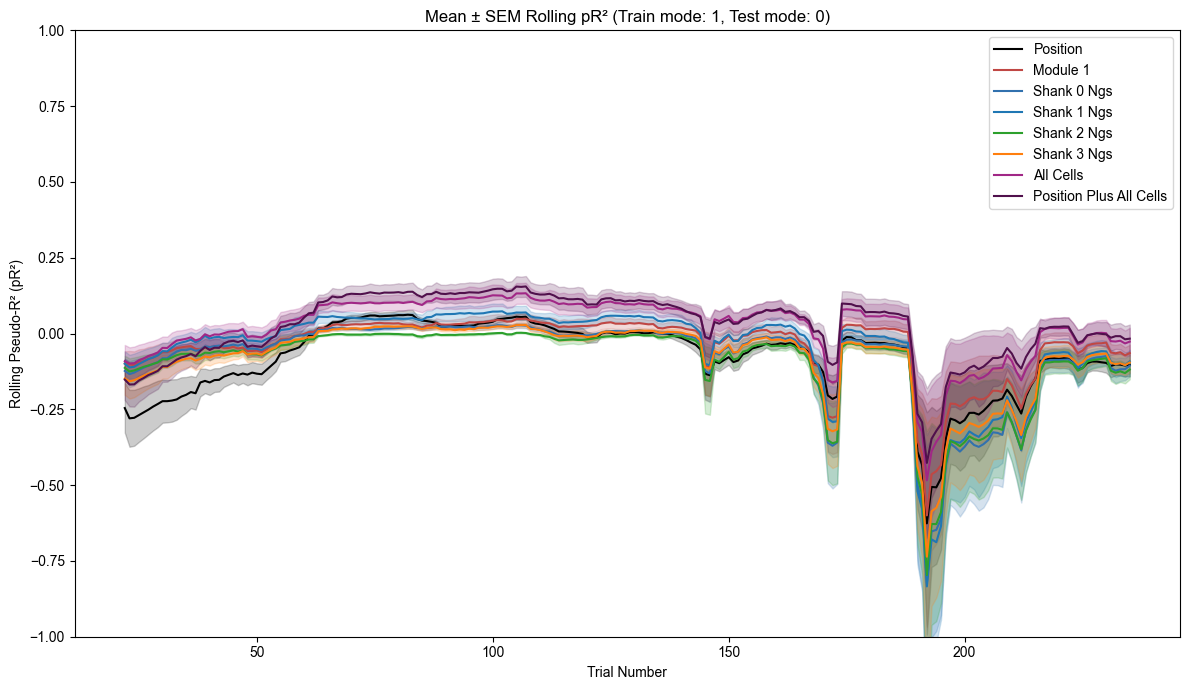

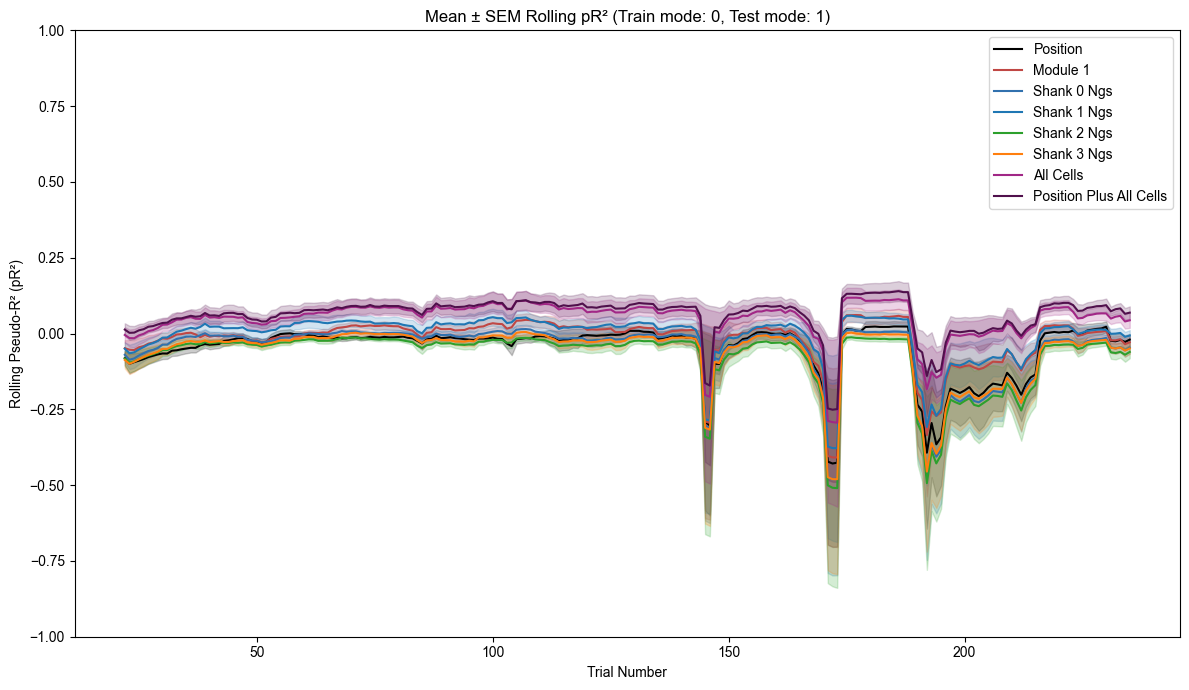

In [16]:
# Combine all rolling results into a single DataFrame
all_rolling_df = pd.concat(all_rolling_results_task_anchoring, ignore_index=True)

# Only keep columns that exist in the DataFrame and have at least one non-NaN value
predictor_cols = ['rolling_pr2_position',
                  'rolling_pr2_module_1',
                  'rolling_pr2_shank_0_ngs',
                  'rolling_pr2_shank_1_ngs',
                  'rolling_pr2_shank_2_ngs',
                  'rolling_pr2_shank_3_ngs',
                  'rolling_pr2_all_cells',
                  'rolling_pr2_position_plus_all_cells',]

color_dict = {
    'rolling_pr2_position': '#000000',
    'rolling_pr2_module_1': '#c04744',
    'rolling_pr2_shank_0_ngs': '#3171ae',
    'rolling_pr2_shank_1_ngs': '#1f77b4',
    'rolling_pr2_shank_2_ngs': '#2ca02c',
    'rolling_pr2_shank_3_ngs': '#ff7f0e',
    'rolling_pr2_all_cells': "#A12786",
    'rolling_pr2_position_plus_all_cells': "#50104c"
}
for train_mode, test_mode in zip([1,0], [0,1]):
        
    # Subset all_rolling_df to only (train_mode, test_mode) = (0,1) and (1,0)
    subset_df = all_rolling_df[((all_rolling_df['train_mode'] == train_mode) & (all_rolling_df['test_mode'] == test_mode))]

    # Group by trial_number and average across test_grid_cell_id
    mean_df = subset_df.groupby('trial_number')[predictor_cols].mean()
    sem_df = subset_df.groupby('trial_number')[predictor_cols].sem()
    plt.figure(figsize=(12, 7))
    plotted_any = False
    for col in predictor_cols:
        if col in mean_df.columns and mean_df[col].notna().any():
            plt.plot(mean_df.index, mean_df[col], color=color_dict.get(col, '#333333'), label=col.replace('rolling_pr2_', '').replace('_', ' ').title())
            plt.fill_between(
                mean_df.index,
                mean_df[col] - sem_df[col],
                mean_df[col] + sem_df[col],
                color=color_dict.get(col, '#333333'), alpha=0.2
            )
            plotted_any = True
    if not plotted_any:
        print(f"No data to plot for train_mode={train_mode}, test_mode={test_mode}.")
    else:
        plt.xlabel('Trial Number')
        plt.ylabel('Rolling Pseudo-R² (pR²)')
        plt.ylim(-1,1)
        plt.title(f'Mean ± SEM Rolling pR² (Train mode: {train_mode}, Test mode: {test_mode})')
        plt.legend()
        plt.tight_layout()
        plt.show()


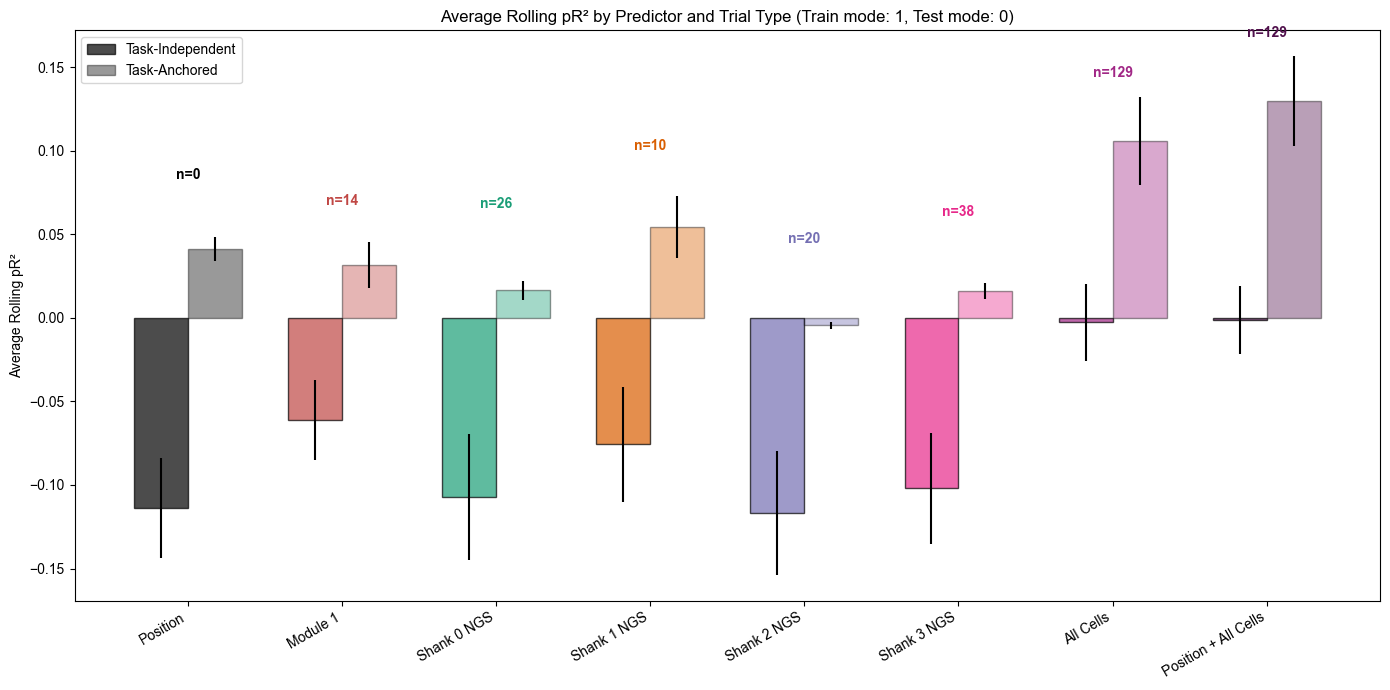

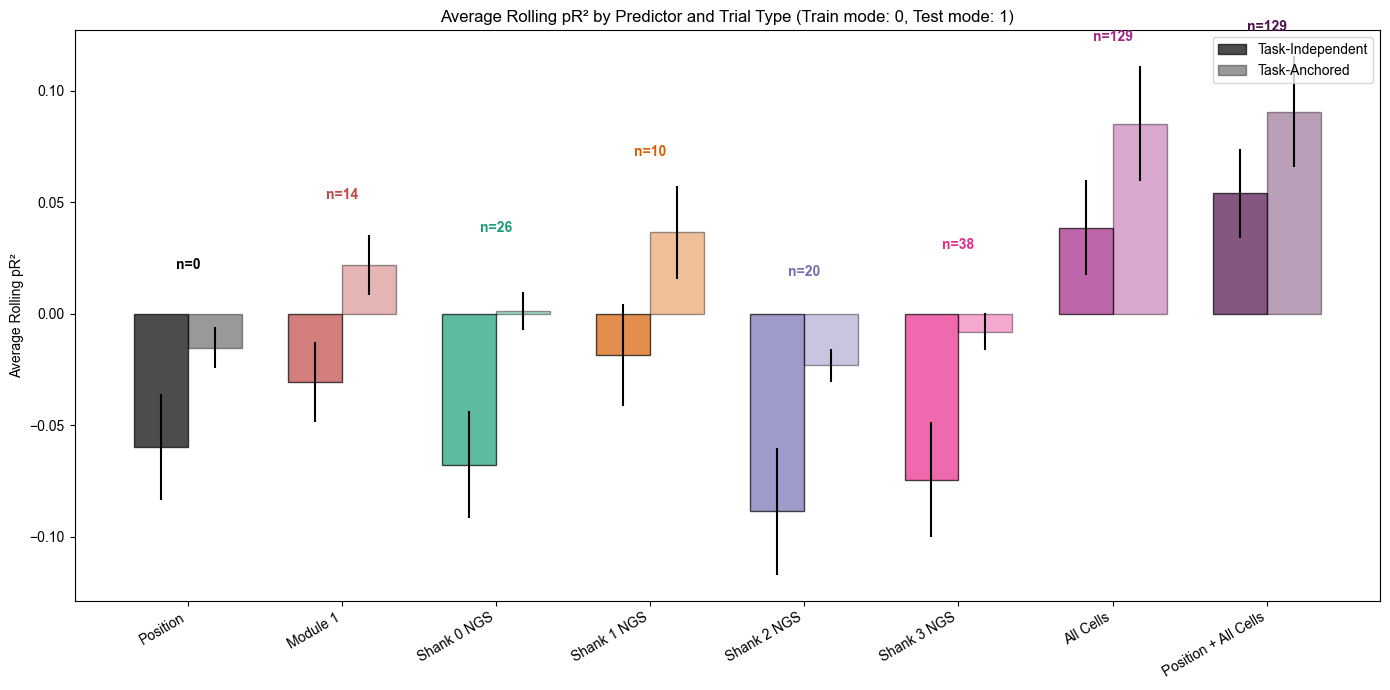

In [17]:
# For each (train_mode, test_mode) pair, plot average pR² for each predictor and each trial label
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

predictors = [
    'rolling_pr2_position',
    'rolling_pr2_module_1',
    'rolling_pr2_shank_0_ngs',
    'rolling_pr2_shank_1_ngs',
    'rolling_pr2_shank_2_ngs',
    'rolling_pr2_shank_3_ngs',
    'rolling_pr2_all_cells',
    'rolling_pr2_position_plus_all_cells'
]
labels = [
    'Position',
    'Module 1',
    'Shank 0 NGS',
    'Shank 1 NGS',
    'Shank 2 NGS',
    'Shank 3 NGS',
    'All Cells',
    'Position + All Cells'
]
colors = ['#000000', '#c04744', '#1b9e77', '#d95f02', '#7570b3', '#e7298a', '#A12786', '#50104c']

n_cells_dict = {
    'rolling_pr2_position': 0,
    'rolling_pr2_module_1': len(g_m_cluster_ids[0])-1,
    'rolling_pr2_shank_0_ngs': len(ngs[ngs.shank_id == 0].cluster_id.values.tolist()),
    'rolling_pr2_shank_1_ngs': len(ngs[ngs.shank_id == 1].cluster_id.values.tolist()),
    'rolling_pr2_shank_2_ngs': len(ngs[ngs.shank_id == 2].cluster_id.values.tolist()),
    'rolling_pr2_shank_3_ngs': len(ngs[ngs.shank_id == 3].cluster_id.values.tolist()),
    'rolling_pr2_all_cells': len(all.cluster_id.values),
    'rolling_pr2_position_plus_all_cells': len(all.cluster_id.values),
}

if isinstance(all_rolling_df, list):
    all_rolling_df = pd.concat(all_rolling_df, ignore_index=True)

for train_mode, test_mode in zip([1,0], [0,1]):
    subset_df = all_rolling_df[(all_rolling_df['train_mode'] == train_mode) & (all_rolling_df['test_mode'] == test_mode)]
    test_ids = subset_df['test_grid_cell_id'].unique()
    means_ti, means_ta, sems_ti, sems_ta = [], [], [], []
    for pred in predictors:
        vals_ti, vals_ta = [], []
        for test_id in test_ids:
            df_cell = subset_df[subset_df['test_grid_cell_id'] == test_id].reset_index(drop=True)
            if 'trial_label' in df_cell.columns:
                mask_ti = (df_cell['trial_label'] == 0)
                mask_ta = (df_cell['trial_label'] == 1)
            else:
                mask_ti = (trial_labels[:len(df_cell)] == 0)
                mask_ta = (trial_labels[:len(df_cell)] == 1)
            vals_ti.append(np.nanmean(df_cell[pred][mask_ti]))
            vals_ta.append(np.nanmean(df_cell[pred][mask_ta]))
        means_ti.append(np.nanmean(vals_ti))
        means_ta.append(np.nanmean(vals_ta))
        sems_ti.append(np.nanstd(vals_ti) / np.sqrt(len(vals_ti)))
        sems_ta.append(np.nanstd(vals_ta) / np.sqrt(len(vals_ta)))
    x = np.arange(len(predictors))
    width = 0.35
    plt.figure(figsize=(14,7))
    bars1 = plt.bar(x - width/2, means_ti, width, yerr=sems_ti, color=colors, alpha=0.7, edgecolor='k', label='Task-Independent')
    bars2 = plt.bar(x + width/2, means_ta, width, yerr=sems_ta, color=colors, alpha=0.4, edgecolor='k', label='Task-Anchored')
    plt.xticks(x, labels, rotation=30, ha='right')
    plt.ylabel('Average Rolling pR²')
    plt.title(f'Average Rolling pR² by Predictor and Trial Type (Train mode: {train_mode}, Test mode: {test_mode})')
    plt.legend()
    for i, pred in enumerate(predictors):
        n_cells = n_cells_dict.get(pred, 0)
        plt.text(i, max(means_ti[i], means_ta[i]) + max(sems_ti[i], sems_ta[i]) + 0.01,
                 f'n={n_cells}', ha='center', va='bottom', fontsize=10, fontweight='bold', color=colors[i])
    plt.tight_layout()
    plt.show()

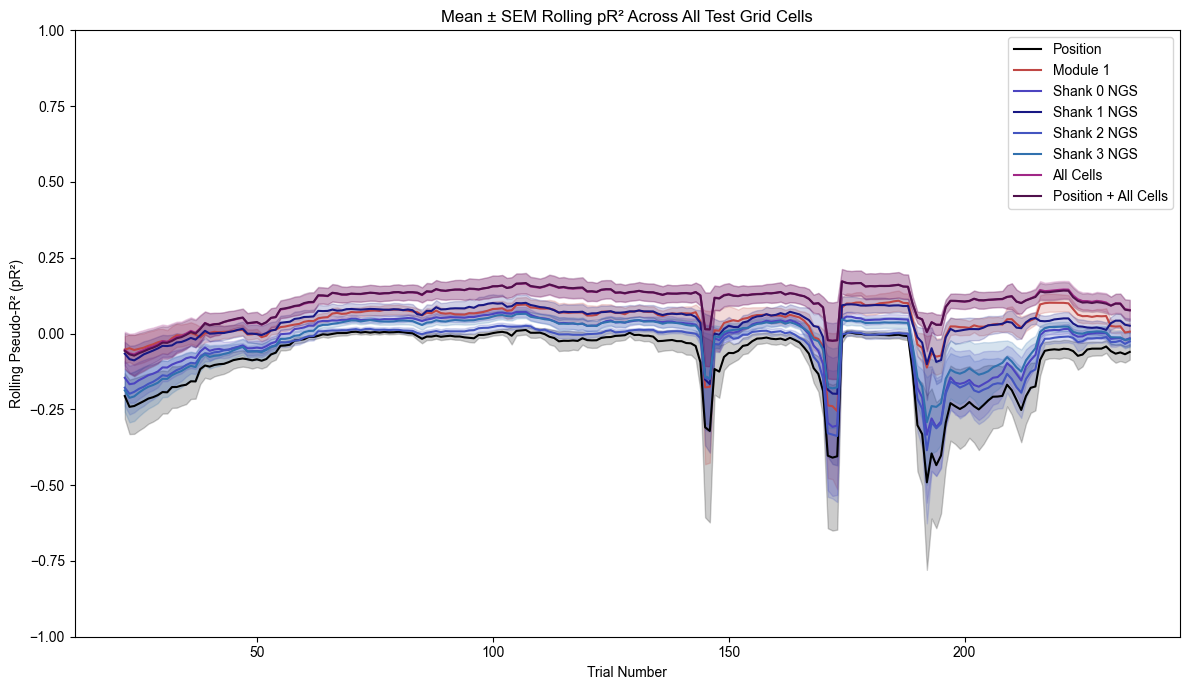

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Store rolling pR² results for each test cell
all_rolling_results = []

for test_grid_cell_id in g_m_cluster_ids[0].copy():
    module_1_ids = g_m_cluster_ids[0].copy()
    module_1_ids.remove(test_grid_cell_id)
    shank_0_ngs = ngs[ngs.shank_id == 0].cluster_id.values.tolist()
    shank_1_ngs = ngs[ngs.shank_id == 1].cluster_id.values.tolist()
    shank_2_ngs = ngs[ngs.shank_id == 2].cluster_id.values.tolist()
    shank_3_ngs = ngs[ngs.shank_id == 3].cluster_id.values.tolist()

    all_cell_ids = all.cluster_id.values.tolist()
    all_cells_except_test = [cid for cid in all_cell_ids if cid != test_grid_cell_id and cid in tcs_time]

    cov_tcs_time_module_1 = {cluster_id: tcs_time[cluster_id] for cluster_id in module_1_ids if cluster_id in tcs_time}
    cov_tcs_time_shank_0_ngs = {cluster_id: tcs_time[cluster_id] for cluster_id in shank_0_ngs if cluster_id in tcs_time}
    cov_tcs_time_shank_1_ngs = {cluster_id: tcs_time[cluster_id] for cluster_id in shank_1_ngs if cluster_id in tcs_time}
    cov_tcs_time_shank_2_ngs = {cluster_id: tcs_time[cluster_id] for cluster_id in shank_2_ngs if cluster_id in tcs_time}
    cov_tcs_time_shank_3_ngs = {cluster_id: tcs_time[cluster_id] for cluster_id in shank_3_ngs if cluster_id in tcs_time}
    
    y = np.array(tcs_time[test_grid_cell_id])
    y_smoothed = gaussian_filter_nan(y, sigma=3)
    X  = np.stack([pos_in_time]).T


    Xm1 = np.column_stack((np.vstack(list(cov_tcs_time_module_1.values())).T)).T
    Xs0 = np.column_stack((np.vstack(list(cov_tcs_time_shank_0_ngs.values())).T)).T
    Xs1 = np.column_stack((np.vstack(list(cov_tcs_time_shank_1_ngs.values())).T)).T
    Xs2 = np.column_stack((np.vstack(list(cov_tcs_time_shank_2_ngs.values())).T)).T
    Xs3 = np.column_stack((np.vstack(list(cov_tcs_time_shank_3_ngs.values())).T)).T
    Xall = np.stack([np.array(tcs_time[cid]) for cid in all_cells_except_test]).T

    Xpos_m1 = np.column_stack((pos_in_time, np.vstack(list(cov_tcs_time_module_1.values())).T))
    X_pos_s0 = np.column_stack((pos_in_time, np.vstack(list(cov_tcs_time_shank_0_ngs.values())).T))
    X_pos_s1 = np.column_stack((pos_in_time, np.vstack(list(cov_tcs_time_shank_1_ngs.values())).T))
    X_pos_s2 = np.column_stack((pos_in_time, np.vstack(list(cov_tcs_time_shank_2_ngs.values())).T))
    X_pos_s3 = np.column_stack((pos_in_time, np.vstack(list(cov_tcs_time_shank_3_ngs.values())).T))
    Xpos_all = np.column_stack((pos_in_time, Xall))

    Y_hat_p, _ = xgb_history.fit_cv(X, y, verbose=0, continuous_folds=True)
    # multiple cell covariate
    Y_hat_m1, _ = xgb_history.fit_cv(Xm1, y, verbose=0, continuous_folds=True)
    Y_hat_s0, _ = xgb_history.fit_cv(Xs0, y, verbose=0, continuous_folds=True)
    Y_hat_s1, _ = xgb_history.fit_cv(Xs1, y, verbose=0, continuous_folds=True)
    Y_hat_s2, _ = xgb_history.fit_cv(Xs2, y, verbose=0, continuous_folds=True)
    Y_hat_s3, _ = xgb_history.fit_cv(Xs3, y, verbose=0, continuous_folds=True)
    Y_hat_all, _ = xgb_history.fit_cv(Xall, y, verbose=0, continuous_folds=True)
    Y_hat_pos_m1, _ = xgb_history.fit_cv(Xpos_m1, y, verbose=0, continuous_folds=True)
    Y_hat_pos_s0, _ = xgb_history.fit_cv(X_pos_s0, y, verbose=0, continuous_folds=True)
    Y_hat_pos_s1, _ = xgb_history.fit_cv(X_pos_s1, y, verbose=0, continuous_folds=True)
    Y_hat_pos_s2, _ = xgb_history.fit_cv(X_pos_s2, y, verbose=0, continuous_folds=True)
    Y_hat_pos_s3, _ = xgb_history.fit_cv(X_pos_s3, y, verbose=0, continuous_folds=True)
    Y_hat_pos_all, _ = xgb_history.fit_cv(Xpos_all, y, verbose=0, continuous_folds=True)

    y_full = np.array(tcs_time[test_grid_cell_id])

    predictions_dict = {
        'position': Y_hat_p,
        'module_1': Y_hat_m1,
        'shank_0_ngs': Y_hat_s0,
        'shank_1_ngs': Y_hat_s1,
        'shank_2_ngs': Y_hat_s2,
        'shank_3_ngs': Y_hat_s3,
        'all_cells': Y_hat_all,
        'position_plus_shank_0_ngs': Y_hat_pos_s0,
        'position_plus_shank_1_ngs': Y_hat_pos_s1,
        'position_plus_shank_2_ngs': Y_hat_pos_s2,
        'position_plus_shank_3_ngs': Y_hat_pos_s3,
        'position_plus_all_cells': Y_hat_pos_all,
    }

    rolling_pr2_results = compute_rolling_pr2_for_all_predictions(
        y_true=y_full, 
        trial_numbers=trial_number_in_time,
        predictions_dict=predictions_dict,
        window_size=15
    )
    rolling_pr2_results['test_grid_cell_id'] = test_grid_cell_id
    all_rolling_results.append(rolling_pr2_results)

# Combine all rolling results into a single DataFrame
all_rolling_df = pd.concat(all_rolling_results, ignore_index=True)

# Compute mean and standard error for each predictor at each trial
predictor_cols = [col for col in all_rolling_df.columns if col.startswith('rolling_pr2_')]
grouped = all_rolling_df.groupby('trial_number')

mean_df = grouped[predictor_cols].mean()
sem_df = grouped[predictor_cols].sem()

# Plot mean ± SEM for each predictor
plt.figure(figsize=(12, 7))
colors = {
    'rolling_pr2_position': '#000000',
    'rolling_pr2_module_1': '#c04744',
    'rolling_pr2_shank_0_ngs': "#4c44c0",
    'rolling_pr2_shank_1_ngs': "#181884",
    'rolling_pr2_shank_2_ngs': "#4455c0",
    'rolling_pr2_shank_3_ngs': '#3171ae',
    'rolling_pr2_all_cells': "#A12786",
    'rolling_pr2_position_plus_all_cells': "#50104c"
}
labels = {
    'rolling_pr2_position': 'Position',
    'rolling_pr2_module_1': 'Module 1',
    'rolling_pr2_shank_0_ngs': 'Shank 0 NGS',
    'rolling_pr2_shank_1_ngs': 'Shank 1 NGS',
    'rolling_pr2_shank_2_ngs': 'Shank 2 NGS',
    'rolling_pr2_shank_3_ngs': 'Shank 3 NGS',
    'rolling_pr2_all_cells': 'All Cells',
    'rolling_pr2_position_plus_all_cells': 'Position + All Cells'
}
for col in colors:
    if col in mean_df.columns:
        plt.plot(mean_df.index, mean_df[col], color=colors[col], label=labels[col])
        plt.fill_between(mean_df.index, mean_df[col] - sem_df[col], mean_df[col] + sem_df[col], color=colors[col], alpha=0.2)
plt.xlabel('Trial Number')
plt.ylabel('Rolling Pseudo-R² (pR²)')
plt.ylim(-1,1)
plt.title('Mean ± SEM Rolling pR² Across All Test Grid Cells')
plt.legend()
plt.tight_layout()
plt.show()

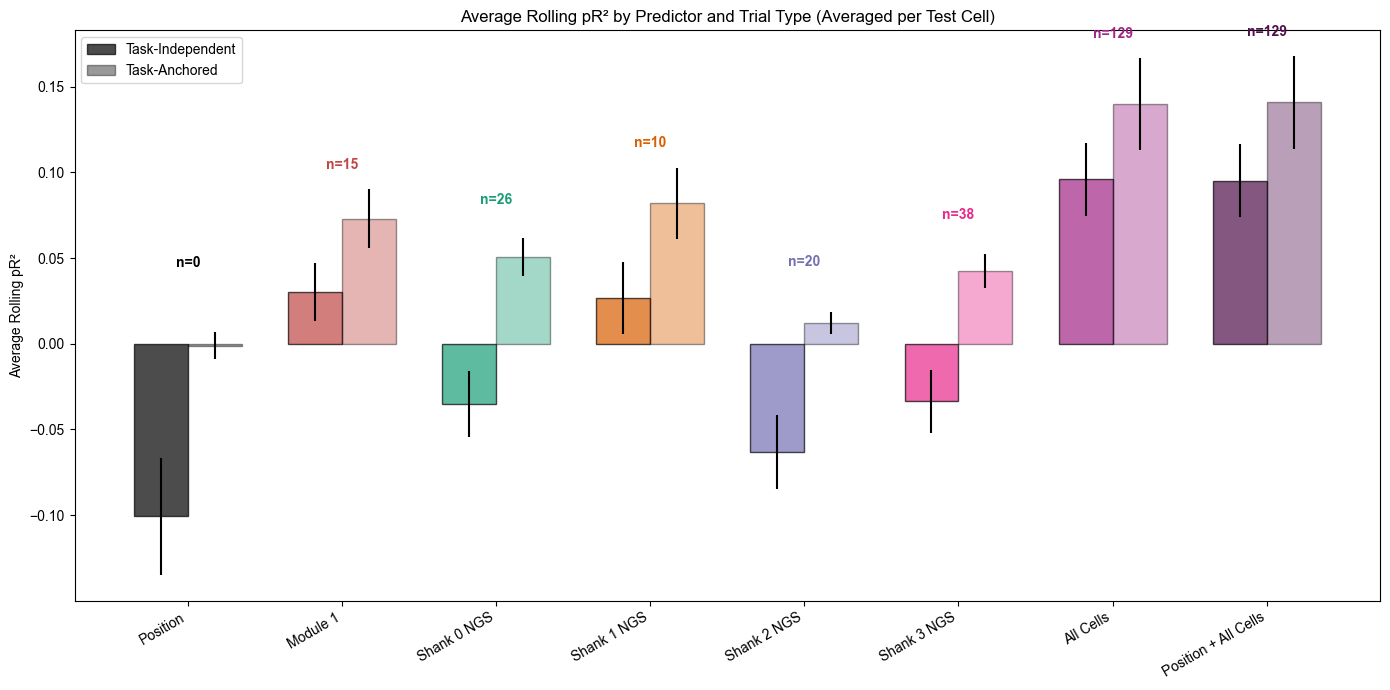

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# predictors and their display labels
predictors = [
    'rolling_pr2_position',
    'rolling_pr2_module_1',
    'rolling_pr2_shank_0_ngs',
    'rolling_pr2_shank_1_ngs',
    'rolling_pr2_shank_2_ngs',
    'rolling_pr2_shank_3_ngs',
    'rolling_pr2_all_cells',
    'rolling_pr2_position_plus_all_cells'
]
labels = [
    'Position',
    'Module 1',
    'Shank 0 NGS',
    'Shank 1 NGS',
    'Shank 2 NGS',
    'Shank 3 NGS',
    'All Cells',
    'Position + All Cells'
]
colors = ['#000000', '#c04744', '#1b9e77', '#d95f02', '#7570b3', '#e7298a', '#A12786', '#50104c']

# Number of cells used for each predictor (customize as needed for your data)
n_cells_dict = {
    'rolling_pr2_position': 0,
    'rolling_pr2_module_1': len(g_m_cluster_ids[0])-1,
    'rolling_pr2_shank_0_ngs': len(ngs[ngs.shank_id == 0].cluster_id.values.tolist()),
    'rolling_pr2_shank_1_ngs': len(ngs[ngs.shank_id == 1].cluster_id.values.tolist()),
    'rolling_pr2_shank_2_ngs': len(ngs[ngs.shank_id == 2].cluster_id.values.tolist()),
    'rolling_pr2_shank_3_ngs': len(ngs[ngs.shank_id == 3].cluster_id.values.tolist()),
    'rolling_pr2_all_cells': len(all.cluster_id.values),
    'rolling_pr2_position_plus_all_cells': len(all.cluster_id.values),
}

# Combine all_rolling_results into a single DataFrame if not already done
if isinstance(all_rolling_results, list):
    all_rolling_df = pd.concat(all_rolling_results, ignore_index=True)
else:
    all_rolling_df = all_rolling_results

# Get unique test_grid_cell_ids
test_ids = all_rolling_df['test_grid_cell_id'].unique()

means_ti = []
means_ta = []
sems_ti = []
sems_ta = []

for pred in predictors:
    vals_ti = []
    vals_ta = []
    for test_id in test_ids:
        df_cell = all_rolling_df[all_rolling_df['test_grid_cell_id'] == test_id].reset_index(drop=True)
        if 'trial_label' in df_cell.columns:
            mask_ti = (df_cell['trial_label'] == 0)
            mask_ta = (df_cell['trial_label'] == 1)
        else:
            mask_ti = (trial_labels[:len(df_cell)] == 0)
            mask_ta = (trial_labels[:len(df_cell)] == 1)
        vals_ti.append(np.nanmean(df_cell[pred][mask_ti]))
        vals_ta.append(np.nanmean(df_cell[pred][mask_ta]))
    means_ti.append(np.nanmean(vals_ti))
    means_ta.append(np.nanmean(vals_ta))
    sems_ti.append(np.nanstd(vals_ti) / np.sqrt(len(vals_ti)))
    sems_ta.append(np.nanstd(vals_ta) / np.sqrt(len(vals_ta)))

x = np.arange(len(predictors))
width = 0.35

plt.figure(figsize=(14,7))
bars1 = plt.bar(x - width/2, means_ti, width, yerr=sems_ti, color=colors, alpha=0.7, edgecolor='k', label='Task-Independent')
bars2 = plt.bar(x + width/2, means_ta, width, yerr=sems_ta, color=colors, alpha=0.4, edgecolor='k', label='Task-Anchored')
plt.xticks(x, labels, rotation=30, ha='right')
plt.ylabel('Average Rolling pR²')
plt.title('Average Rolling pR² by Predictor and Trial Type (Averaged per Test Cell)')
plt.legend()

# Annotate number of cells above each bar group
for i, pred in enumerate(predictors):
    n_cells = n_cells_dict.get(pred, 0)
    plt.text(i, max(means_ti[i], means_ta[i]) + max(sems_ti[i], sems_ta[i]) + 0.01,
             f'n={n_cells}', ha='center', va='bottom', fontsize=10, fontweight='bold', color=colors[i])

plt.tight_layout()
plt.show()

making the plot for all shank cells and grid cell module

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Define the test cell groups
cell_groups = [
    ('Module 1', g_m_cluster_ids[0].copy()),
    ('Shank 0 NGS', ngs[ngs.shank_id == 0].cluster_id.values.tolist()),
    ('Shank 1 NGS', ngs[ngs.shank_id == 1].cluster_id.values.tolist()),
    ('Shank 2 NGS', ngs[ngs.shank_id == 2].cluster_id.values.tolist()),
    ('Shank 3 NGS', ngs[ngs.shank_id == 3].cluster_id.values.tolist()),
]

all_rolling_results_by_group = {}

for group_name, test_cell_ids in cell_groups:
    all_rolling_results = []
    for ti, test_cell_id in enumerate(test_cell_ids.copy()):
        print(f'processing {group_name}, id {ti}/{len(test_cell_ids)}')
        # Remove test cell from the group for covariate construction
        module_1_ids = g_m_cluster_ids[0].copy()
        if test_cell_id in module_1_ids:
            module_1_ids.remove(test_cell_id)
        shank_0_ngs = ngs[ngs.shank_id == 0].cluster_id.values.tolist()
        if test_cell_id in shank_0_ngs:
            shank_0_ngs.remove(test_cell_id)
        shank_1_ngs = ngs[ngs.shank_id == 1].cluster_id.values.tolist()
        if test_cell_id in shank_1_ngs:
            shank_1_ngs.remove(test_cell_id)
        shank_2_ngs = ngs[ngs.shank_id == 2].cluster_id.values.tolist()
        if test_cell_id in shank_2_ngs:
            shank_2_ngs.remove(test_cell_id)
        shank_3_ngs = ngs[ngs.shank_id == 3].cluster_id.values.tolist()
        if test_cell_id in shank_3_ngs:
            shank_3_ngs.remove(test_cell_id)
        all_cell_ids = all.cluster_id.values.tolist()
        all_cells_except_test = [cid for cid in all_cell_ids if cid != test_cell_id and cid in tcs_time]
        cov_tcs_time_module_1 = {cluster_id: tcs_time[cluster_id] for cluster_id in module_1_ids if cluster_id in tcs_time}
        cov_tcs_time_shank_0_ngs = {cluster_id: tcs_time[cluster_id] for cluster_id in shank_0_ngs if cluster_id in tcs_time}
        cov_tcs_time_shank_1_ngs = {cluster_id: tcs_time[cluster_id] for cluster_id in shank_1_ngs if cluster_id in tcs_time}
        cov_tcs_time_shank_2_ngs = {cluster_id: tcs_time[cluster_id] for cluster_id in shank_2_ngs if cluster_id in tcs_time}
        cov_tcs_time_shank_3_ngs = {cluster_id: tcs_time[cluster_id] for cluster_id in shank_3_ngs if cluster_id in tcs_time}
        y = np.array(tcs_time[test_cell_id])
        y_smoothed = gaussian_filter_nan(y, sigma=3)
        X  = np.stack([pos_in_time]).T
        Xm1 = np.column_stack((np.vstack(list(cov_tcs_time_module_1.values())).T)).T
        Xs0 = np.column_stack((np.vstack(list(cov_tcs_time_shank_0_ngs.values())).T)).T
        Xs1 = np.column_stack((np.vstack(list(cov_tcs_time_shank_1_ngs.values())).T)).T
        Xs2 = np.column_stack((np.vstack(list(cov_tcs_time_shank_2_ngs.values())).T)).T
        Xs3 = np.column_stack((np.vstack(list(cov_tcs_time_shank_3_ngs.values())).T)).T
        Xall = np.stack([np.array(tcs_time[cid]) for cid in all_cells_except_test]).T
        Xpos_m1 = np.column_stack((pos_in_time, np.vstack(list(cov_tcs_time_module_1.values())).T))
        X_pos_s0 = np.column_stack((pos_in_time, np.vstack(list(cov_tcs_time_shank_0_ngs.values())).T))
        X_pos_s1 = np.column_stack((pos_in_time, np.vstack(list(cov_tcs_time_shank_1_ngs.values())).T))
        X_pos_s2 = np.column_stack((pos_in_time, np.vstack(list(cov_tcs_time_shank_2_ngs.values())).T))
        X_pos_s3 = np.column_stack((pos_in_time, np.vstack(list(cov_tcs_time_shank_3_ngs.values())).T))
        Xpos_all = np.column_stack((pos_in_time, Xall))
        Y_hat_p, _ = xgb_history.fit_cv(X, y, verbose=0, continuous_folds=True)
        Y_hat_m1, _ = xgb_history.fit_cv(Xm1, y, verbose=0, continuous_folds=True)
        Y_hat_s0, _ = xgb_history.fit_cv(Xs0, y, verbose=0, continuous_folds=True)
        Y_hat_s1, _ = xgb_history.fit_cv(Xs1, y, verbose=0, continuous_folds=True)
        Y_hat_s2, _ = xgb_history.fit_cv(Xs2, y, verbose=0, continuous_folds=True)
        Y_hat_s3, _ = xgb_history.fit_cv(Xs3, y, verbose=0, continuous_folds=True)
        Y_hat_all, _ = xgb_history.fit_cv(Xall, y, verbose=0, continuous_folds=True)
        Y_hat_pos_m1, _ = xgb_history.fit_cv(Xpos_m1, y, verbose=0, continuous_folds=True)
        Y_hat_pos_s0, _ = xgb_history.fit_cv(X_pos_s0, y, verbose=0, continuous_folds=True)
        Y_hat_pos_s1, _ = xgb_history.fit_cv(X_pos_s1, y, verbose=0, continuous_folds=True)
        Y_hat_pos_s2, _ = xgb_history.fit_cv(X_pos_s2, y, verbose=0, continuous_folds=True)
        Y_hat_pos_s3, _ = xgb_history.fit_cv(X_pos_s3, y, verbose=0, continuous_folds=True)
        Y_hat_pos_all, _ = xgb_history.fit_cv(Xpos_all, y, verbose=0, continuous_folds=True)
        y_full = np.array(tcs_time[test_cell_id])
        predictions_dict = {
            'position': Y_hat_p,
            'module_1': Y_hat_m1,
            'shank_0_ngs': Y_hat_s0,
            'shank_1_ngs': Y_hat_s1,
            'shank_2_ngs': Y_hat_s2,
            'shank_3_ngs': Y_hat_s3,
            'all_cells': Y_hat_all,
            'position_plus_shank_0_ngs': Y_hat_pos_s0,
            'position_plus_shank_1_ngs': Y_hat_pos_s1,
            'position_plus_shank_2_ngs': Y_hat_pos_s2,
            'position_plus_shank_3_ngs': Y_hat_pos_s3,
            'position_plus_all_cells': Y_hat_pos_all,
        }
        rolling_pr2_results = compute_rolling_pr2_for_all_predictions(
            y_true=y_full, 
            trial_numbers=trial_number_in_time,
            predictions_dict=predictions_dict,
            window_size=15
        )
        rolling_pr2_results['test_cell_id'] = test_cell_id
        all_rolling_results.append(rolling_pr2_results)
    # Combine all rolling results into a single DataFrame for this group
    all_rolling_df = pd.concat(all_rolling_results, ignore_index=True)
    all_rolling_results_by_group[group_name] = all_rolling_df

# Now, for each group, plot the bar plot as in the second code block
predictors = [
    'rolling_pr2_position',
    'rolling_pr2_module_1',
    'rolling_pr2_shank_0_ngs',
    'rolling_pr2_shank_1_ngs',
    'rolling_pr2_shank_2_ngs',
    'rolling_pr2_shank_3_ngs',
    'rolling_pr2_all_cells',
    'rolling_pr2_position_plus_all_cells'
]
labels = [
    'Position',
    'Module 1',
    'Shank 0 NGS',
    'Shank 1 NGS',
    'Shank 2 NGS',
    'Shank 3 NGS',
    'All Cells',
    'Position + All Cells'
]
colors = ['#000000', '#c04744', '#1b9e77', '#d95f02', '#7570b3', '#e7298a', '#A12786', '#50104c']
n_cells_dict = {
    'rolling_pr2_position': 0,
    'rolling_pr2_module_1': len(g_m_cluster_ids[0])-1,
    'rolling_pr2_shank_0_ngs': len(ngs[ngs.shank_id == 0].cluster_id.values.tolist()),
    'rolling_pr2_shank_1_ngs': len(ngs[ngs.shank_id == 1].cluster_id.values.tolist()),
    'rolling_pr2_shank_2_ngs': len(ngs[ngs.shank_id == 2].cluster_id.values.tolist()),
    'rolling_pr2_shank_3_ngs': len(ngs[ngs.shank_id == 3].cluster_id.values.tolist()),
    'rolling_pr2_all_cells': len(all.cluster_id.values),
    'rolling_pr2_position_plus_all_cells': len(all.cluster_id.values),
}
for group_name, all_rolling_df in all_rolling_results_by_group.items():
    test_ids = all_rolling_df['test_cell_id'].unique()
    means_ti, means_ta, sems_ti, sems_ta = [], [], [], []
    for pred in predictors:
        vals_ti, vals_ta = [], []
        for test_id in test_ids:
            df_cell = all_rolling_df[all_rolling_df['test_cell_id'] == test_id].reset_index(drop=True)
            if 'trial_label' in df_cell.columns:
                mask_ti = (df_cell['trial_label'] == 0)
                mask_ta = (df_cell['trial_label'] == 1)
            else:
                mask_ti = (trial_labels[:len(df_cell)] == 0)
                mask_ta = (trial_labels[:len(df_cell)] == 1)
            vals_ti.append(np.nanmean(df_cell[pred][mask_ti]))
            vals_ta.append(np.nanmean(df_cell[pred][mask_ta]))
        means_ti.append(np.nanmean(vals_ti))
        means_ta.append(np.nanmean(vals_ta))
        sems_ti.append(np.nanstd(vals_ti) / np.sqrt(len(vals_ti)))
        sems_ta.append(np.nanstd(vals_ta) / np.sqrt(len(vals_ta)))
    x = np.arange(len(predictors))
    width = 0.35
    plt.figure(figsize=(14,7))
    bars1 = plt.bar(x - width/2, means_ti, width, yerr=sems_ti, color=colors, alpha=0.7, edgecolor='k', label='Task-Independent')
    bars2 = plt.bar(x + width/2, means_ta, width, yerr=sems_ta, color=colors, alpha=0.4, edgecolor='k', label='Task-Anchored')
    plt.xticks(x, labels, rotation=30, ha='right')
    plt.ylabel('Average Rolling pR²')
    plt.title(f'{group_name}: Average Rolling pR² by Predictor and Trial Type (Averaged per Test Cell)')
    plt.legend()
    for i, pred in enumerate(predictors):
        n_cells = n_cells_dict.get(pred, 0)
        plt.text(i, max(means_ti[i], means_ta[i]) + max(sems_ti[i], sems_ta[i]) + 0.01,
                 f'n={n_cells}', ha='center', va='bottom', fontsize=10, fontweight='bold', color=colors[i])
    plt.tight_layout()
    plt.show()

processing Module 1, id 0/15
processing Module 1, id 1/15
processing Module 1, id 1/15
processing Module 1, id 2/15
processing Module 1, id 2/15
